# Teaching Demo
Sun Ju Lee
11/5/24 @ Bucknell

# Part 1 (Fitting the model)

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams.update({'figure.autolayout': True})

In [62]:
# What does the data look like?

pa = pd.read_csv("data_pct_diff.csv")
pa

,county,percent_diff_rep,vote_2020
0,Adams,31.7,1
1,Allegheny,-27.0,0
2,Armstrong,35.8,1
3,Beaver,2.1,1
4,Bedford,56.3,1
...,...,...,...
61,Washington,10.4,1
62,Wayne,33.0,1
63,Westmoreland,14.7,1
64,Wyoming,34.6,1


In [63]:
# Get X and y
# X = % difference in voting registration
# y = voting result where 1 indicates red (Rep), 0 indicates blue (Dem)

X = pa.iloc[:,1].to_numpy().reshape(-1,1)
y = pa.iloc[:,2]

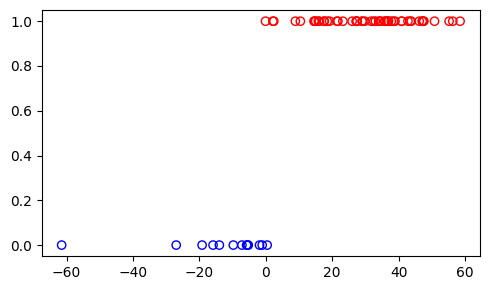

In [88]:
# Plot the data

fig = plt.figure(figsize=(5,3))
ax = fig.add_subplot(111)

ax.scatter(X[y==1],y[y==1], marker = 'o', facecolors='none', edgecolors='r')
ax.scatter(X[y==0],y[y==0], marker = 'o',facecolors='none', edgecolors='b')

plt.show()

In [89]:
# Fit a logistic model, get the coefficient and intercept

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(penalty = 'none').fit(X, y)

In [66]:
print("Coefficient: ", clf.coef_[0][0])
print("Intercept: ", clf.intercept_[0])

Coefficient:  1.7065090595628383
Intercept:  -0.3783588660559433


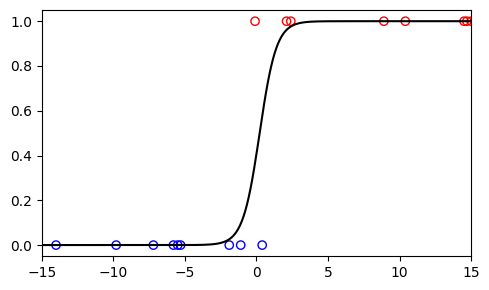

In [60]:
# Plot the logistic function on top of the data

fig = plt.figure(figsize=(5,3))
ax = fig.add_subplot(111)

# Get xs and ys for the logistic function
xs = np.linspace(-60,60,1000)
def f(x):
    return 1/(1+np.exp(-(clf.intercept_[0] + clf.coef_[0][0]*x)))
ys = f(xs)

ax.scatter(X[y==1],y[y==1], marker = 'o', facecolors='none', edgecolors='r')
ax.scatter(X[y==0],y[y==0], marker = 'o',facecolors='none', edgecolors='b')
ax.plot(xs, ys, 'black')

plt.xlim(-15,15)
plt.show()

# Part 2 (Prediction)

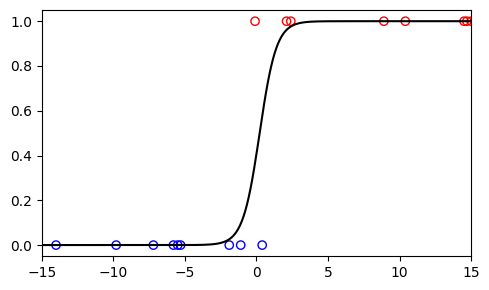

In [70]:
# Plot new data

X_test = 0.465

fig = plt.figure(figsize=(5,3))
ax = fig.add_subplot(111)

# Get xs and ys for the logistic function
xs = np.linspace(-60,60,1000)
def f(x):
    return 1/(1+np.exp(-(clf.intercept_[0] + clf.coef_[0][0]*x)))
ys = f(xs)

ax.scatter(X[y==1],y[y==1], marker = 'o', facecolors='none', edgecolors='r')
ax.scatter(X[y==0],y[y==0], marker = 'o',facecolors='none', edgecolors='b')
ax.plot(xs, ys, 'black')

plt.xlim(-15,15)
plt.show()

In [14]:
# Get prediction - using Python

clf.predict_proba(np.array(X_test).reshape(-1,1))

array([[0.39767362, 0.60232638]])

In [15]:
# Get prediction - using the logistic function directly

1/(1+np.exp(-(clf.intercept_[0] + clf.coef_[0][0]*X_test)))

0.6023263817693792

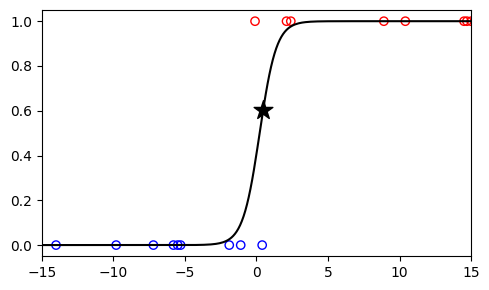

In [85]:
# Plot new data

X_test = 0.465

fig = plt.figure(figsize=(5,3))
ax = fig.add_subplot(111)

# Get xs and ys for the logistic function
xs = np.linspace(-60,60,1000)
def f(x):
    return 1/(1+np.exp(-(clf.intercept_[0] + clf.coef_[0][0]*x)))
ys = f(xs)

ax.scatter(X[y==1],y[y==1], marker = 'o', facecolors='none', edgecolors='r')
ax.scatter(X[y==0],y[y==0], marker = 'o',facecolors='none', edgecolors='b')
ax.plot(xs, ys, 'black')
ax.scatter(X_test, f(X_test), marker = '*', color = 'black', s = 200)

plt.xlim(-15,15)
plt.show()